### 1. Import necessary libraries

In [1]:
import os, sys, h5py, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from __future__ import annotations


In [2]:
PROJECT_ROOT = Path.cwd()
# If the notebook was launched from notebooks/, go up one level.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
PROJECT_ROOT, SRC_DIR

(PosixPath('/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm'),
 PosixPath('/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm/src'))

### 2. Check activations for all layers

In [3]:
data_dir = "../results/baseline/activations_32b.h5"

# Peek into the structure of the HDF5 file to understand how the data is organized
with h5py.File(data_dir, "r") as f_in:
    print("Inside emotional:", list(f_in["emotional"].keys()))
    print("Inside emotions [Eg. Angry]:", list(f_in["emotional"]["angry"].keys()))
    print("Inside neutral:", list(f_in["neutral"].keys()))

Inside emotional: ['afraid', 'angry', 'calm', 'desperate', 'guilty', 'happy', 'inspired', 'loving', 'nervous', 'proud', 'sad', 'surprised']
Inside emotions [Eg. Angry]: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']
Inside neutral: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']


### 3. Open the file, read and save the activations for further analysis

##### Initialize the EmotionVectorExtractor

In [4]:
from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

activations_path = "../results/baseline/activations_32b.h5"
layer_indices = cfg.LAYER_INDICES_32B
emotions_extractor = EmotionVectorExtractor(activations_path=activations_path, 
                                    layer_indices=layer_indices)

In [5]:
my_activations = emotions_extractor.load_activations()
print("First Layer Emotional Activation Keys:", emotions_extractor.activations[0]["emotional"].keys())

print("First Layer Emotional Activation value shapes:", {emotion: values.shape
        for emotion, values in emotions_extractor.activations[0]["emotional"].items()})
print("First Layer Neutral Activation Shape:", emotions_extractor.activations[0]["neutral"].shape)

First Layer Emotional Activation Keys: dict_keys(['happy', 'inspired', 'loving', 'proud', 'calm', 'desperate', 'angry', 'afraid', 'nervous', 'guilty', 'sad', 'surprised'])
First Layer Emotional Activation value shapes: {'happy': (190, 5120), 'inspired': (192, 5120), 'loving': (192, 5120), 'proud': (191, 5120), 'calm': (192, 5120), 'desperate': (192, 5120), 'angry': (190, 5120), 'afraid': (192, 5120), 'nervous': (191, 5120), 'guilty': (192, 5120), 'sad': (191, 5120), 'surprised': (190, 5120)}
First Layer Neutral Activation Shape: (48, 5120)


### 4. Define a method for PCA denoising

In [6]:
cleaned_emotions_by_layer = {}
for layer in layer_indices:
    cleaned_emotions_by_layer[layer] = emotions_extractor.pca_denoise(layer=layer)

Layer 0: Retaining 10 PCA components to preserve 50.0% variance
Layer 16: Retaining 1 PCA components to preserve 50.0% variance
Layer 32: Retaining 1 PCA components to preserve 50.0% variance
Layer 38: Retaining 1 PCA components to preserve 50.0% variance
Layer 42: Retaining 1 PCA components to preserve 50.0% variance
Layer 46: Retaining 1 PCA components to preserve 50.0% variance
Layer 50: Retaining 3 PCA components to preserve 50.0% variance
Layer 56: Retaining 5 PCA components to preserve 50.0% variance


### 5. Plot them!!! 

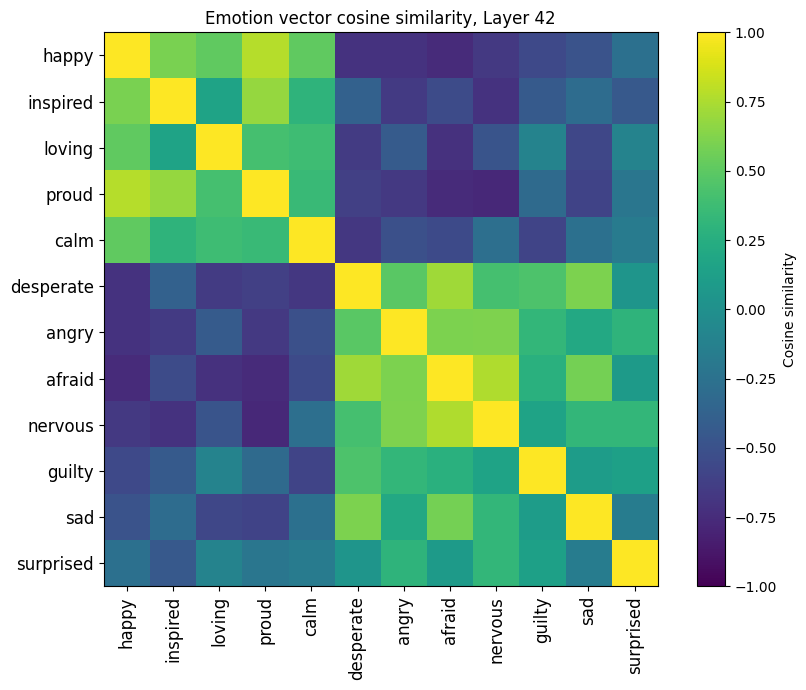

In [7]:
emotions = list(cleaned_emotions_by_layer[42].keys())
V = np.stack([cleaned_emotions_by_layer[42][emotion] for emotion in emotions])

cos_sim = cosine_similarity(V)

plt.figure(figsize=(9, 7))
plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(emotions)), emotions, rotation=90, fontsize=12)
plt.yticks(range(len(emotions)), emotions, fontsize=12)
plt.title(f"Emotion vector cosine similarity, Layer 42", fontsize=12)
plt.tight_layout()
plt.show()

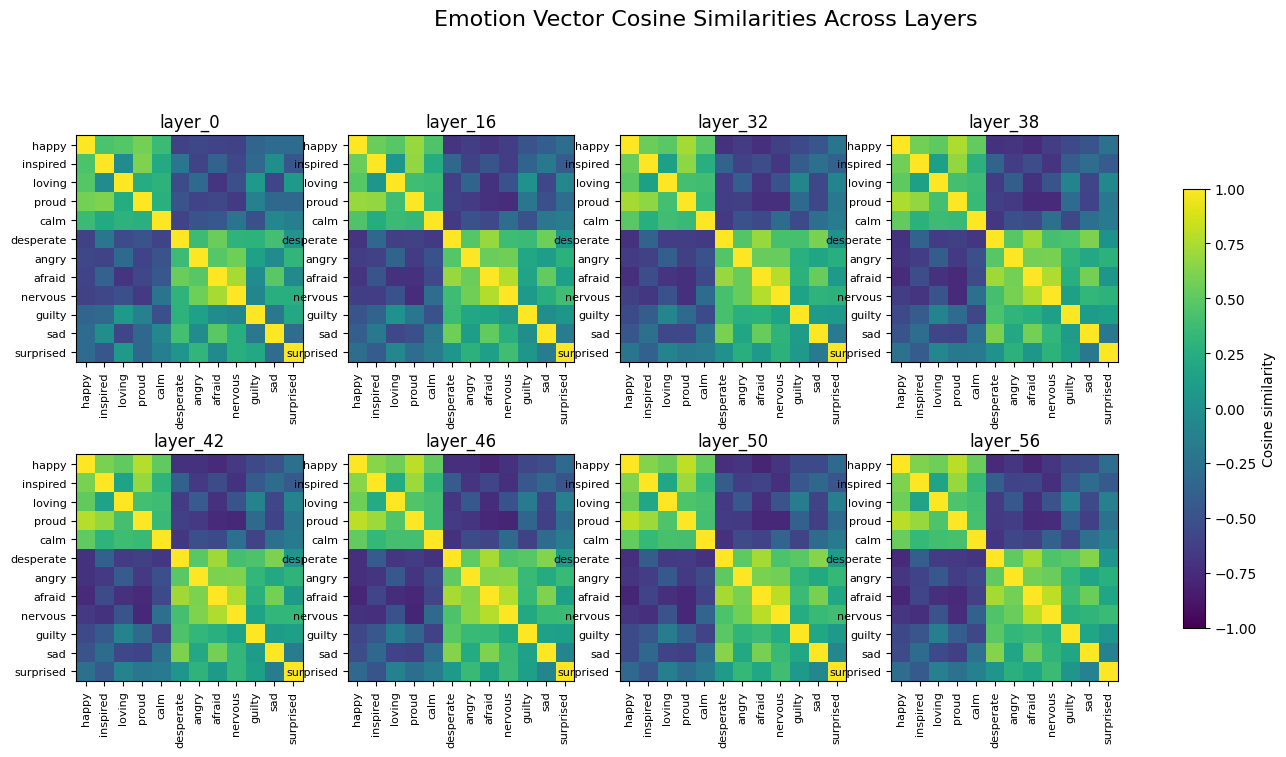

In [8]:
emotions = cfg.EMOTIONS

with h5py.File(data_dir, "r") as f_in:
    layers_to_plot = sorted(
        f_in["neutral"].keys(),
        key=lambda name: int(name.replace("layer_", "")),
    )

n_layers = len(layers_to_plot)
n_cols = min(4, n_layers)
n_rows = int(np.ceil(n_layers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), squeeze=False)

last_im = None
for ax, layer_name in zip(axes.flat, layers_to_plot):
    layer_idx = int(layer_name.replace("layer_", ""))
    V = np.stack([cleaned_emotions_by_layer[layer_idx][e] for e in emotions])
    cos_sim = cosine_similarity(V)
    last_im = ax.imshow(cos_sim, vmin=-1, vmax=1)
    ax.set_title(layer_name, fontsize=12)
    ax.set_xticks(range(len(emotions)))
    ax.set_yticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=90, fontsize=8)
    ax.set_yticklabels(emotions, fontsize=8)

for ax in axes.flat[n_layers:]:
    ax.axis("off")

fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.75, label="Cosine similarity")
fig.suptitle("Emotion Vector Cosine Similarities Across Layers", fontsize=16, y=1.02)
plt.show()

In [9]:
print(layers_to_plot)

['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']


Explained variance ratio: [0.5005776  0.13257803]
Total variance explained: 0.63315564


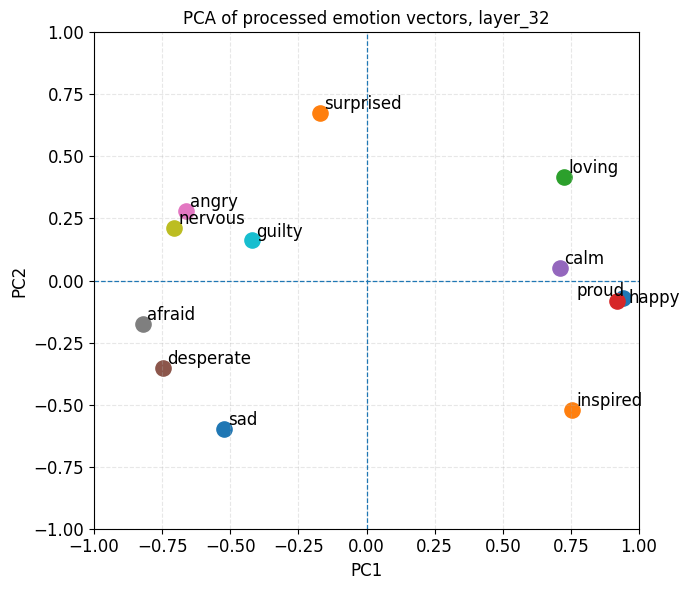

In [10]:
inspect_layer = layers_to_plot[2]
cleaned_emotions = cleaned_emotions_by_layer[int(inspect_layer.replace("layer_", ""))]

# Stack emotion vectors
emotions = list(cleaned_emotions.keys())
V = np.stack([cleaned_emotions[e] for e in emotions])

# PCA to 2D
pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(7, 6))

for i, emotion in enumerate(emotions):
    x, y = V_2d[i]
    plt.scatter(x, y, s=120)
    if emotion not in ["happy", "proud"]:
        plt.text(x + 0.015, y + 0.015, emotion, fontsize=12)
    elif emotion == "proud":
        plt.text(x - 0.15, y + 0.02, emotion, fontsize=12)
    else:
        plt.text(x + 0.02, y - 0.018, emotion, rotation=0, fontsize=12)


plt.axhline(0, linewidth=0.9, linestyle="--")
plt.axvline(0, linewidth=0.9, linestyle="--")

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA of processed emotion vectors, {inspect_layer}", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### And it works!!!!!

### 6. Identifying the best layer for emotion vectors

In [11]:
import emotion_mechanisms.vectors as vectors
vectors.main(activations_path=activations_path, layer_indices=layer_indices)


Probe directions layer 56: 100%|██████████| 12/12 [01:41<00:00,  8.50s/emotion]

Best layer: 32
Probe metrics: {'happy': {'accuracy': 0.9647058823529413, 'balanced_accuracy': 0.8849981247655958, 'f1': 0.7867532442874907, 'average_precision': 0.8656180743207381, 'roc_auc': 0.984710588823603, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9694989106753813, 'balanced_accuracy': 0.895594332533325, 'f1': 0.8133290288219864, 'average_precision': 0.9194630026387506, 'roc_auc': 0.9840046947260349, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9821350762527233, 'balanced_accuracy': 0.9498278264636559, 'f1': 0.8947630033637737, 'average_precision': 0.9527662927945306, 'roc_auc': 0.9923828283785779, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9616557734204794, 'balanced_accuracy': 0.8526828490924002, 'f1': 0.7585681437879176, 'average_precision': 0.8110742169493228, 'roc_auc': 0.9726003891512081, 'ma

### Making this output human readable

In [12]:
probe_metrics = {'happy': {'accuracy': 0.9647058823529413, 'balanced_accuracy': 0.8849981247655958, 'f1': 0.7867532442874907, 'average_precision': 0.8656180743207381, 'roc_auc': 0.984710588823603, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9694989106753813, 'balanced_accuracy': 0.895594332533325, 'f1': 0.8133290288219864, 'average_precision': 0.9194630026387506, 'roc_auc': 0.9840046947260349, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9821350762527233, 'balanced_accuracy': 0.9498278264636559, 'f1': 0.8947630033637737, 'average_precision': 0.9527662927945306, 'roc_auc': 0.9923828283785779, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9616557734204794, 'balanced_accuracy': 0.8526828490924002, 'f1': 0.7585681437879176, 'average_precision': 0.8110742169493228, 'roc_auc': 0.9726003891512081, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9847494553376906, 'balanced_accuracy': 0.9606942488690207, 'f1': 0.9101499510792914, 'average_precision': 0.9707935628583806, 'roc_auc': 0.9951918898287193, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9481481481481481, 'balanced_accuracy': 0.8249779459611938, 'f1': 0.6856633995206455, 'average_precision': 0.7498178709658225, 'roc_auc': 0.9584907576206488, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9930283224400872, 'balanced_accuracy': 0.9746530816352046, 'f1': 0.9573087408703846, 'average_precision': 0.9893055840664507, 'roc_auc': 0.9988498562320289, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9337690631808279, 'balanced_accuracy': 0.7838926820980827, 'f1': 0.604004194917321, 'average_precision': 0.6367522829560465, 'roc_auc': 0.9332039108673686, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9464052287581699, 'balanced_accuracy': 0.8209652351232549, 'f1': 0.6745529988253904, 'average_precision': 0.7378204220642892, 'roc_auc': 0.9552453290483044, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9773420479302832, 'balanced_accuracy': 0.9238120561773518, 'f1': 0.8636287740125008, 'average_precision': 0.94607795580876, 'roc_auc': 0.9921839237841237, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9677559912854031, 'balanced_accuracy': 0.8921872125041272, 'f1': 0.8033244401820253, 'average_precision': 0.8667437546862857, 'roc_auc': 0.9771560196550819, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9616557734204794, 'balanced_accuracy': 0.8641830228778596, 'f1': 0.7611976364917542, 'average_precision': 0.847282523460472, 'roc_auc': 0.9755719464933117, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}
all_metrics: {0: {'happy': {'accuracy': 0.918954248366013, 'balanced_accuracy': 0.8026003250406302, 'f1': 0.5759583313217881, 'average_precision': 0.6364924894658329, 'roc_auc': 0.9286910863857983, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9394335511982572, 'balanced_accuracy': 0.8317836913680144, 'f1': 0.6585086930294908, 'average_precision': 0.7439642249326832, 'roc_auc': 0.9439983798341093, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9490196078431372, 'balanced_accuracy': 0.8796338553308175, 'f1': 0.7226758881950164, 'average_precision': 0.8074493670566311, 'roc_auc': 0.9689951124842986, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9159041394335512, 'balanced_accuracy': 0.7613059599482902, 'f1': 0.5322303494717288, 'average_precision': 0.5655086246794715, 'roc_auc': 0.9277843414798033, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.962091503267974, 'balanced_accuracy': 0.9036570024549772, 'f1': 0.7870660841793906, 'average_precision': 0.8584443122731757, 'roc_auc': 0.981261488577403, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9019607843137255, 'balanced_accuracy': 0.7527711224892122, 'f1': 0.49555814788915153, 'average_precision': 0.49992819941047495, 'roc_auc': 0.8935408806442686, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9660130718954247, 'balanced_accuracy': 0.9144393049131141, 'f1': 0.8068795627412758, 'average_precision': 0.9009562979929356, 'roc_auc': 0.9869858732341543, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.89760348583878, 'balanced_accuracy': 0.7687362408396288, 'f1': 0.49835034113206966, 'average_precision': 0.4818923712967299, 'roc_auc': 0.8984047654919014, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.8840958605664488, 'balanced_accuracy': 0.7156363386998467, 'f1': 0.42408237129806, 'average_precision': 0.4276233479906974, 'roc_auc': 0.8791666418619787, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9328976034858387, 'balanced_accuracy': 0.8357987033177683, 'f1': 0.6453652190677361, 'average_precision': 0.7036947547155454, 'roc_auc': 0.9528060238299018, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9237472766884534, 'balanced_accuracy': 0.8251582958858868, 'f1': 0.6069985434873075, 'average_precision': 0.6704502997228614, 'roc_auc': 0.9370385187037268, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9124183006535947, 'balanced_accuracy': 0.7583385423177897, 'f1': 0.5174614385792224, 'average_precision': 0.5448003530574889, 'roc_auc': 0.8950743842980373, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 16: {'happy': {'accuracy': 0.9533769063180827, 'balanced_accuracy': 0.845305663207901, 'f1': 0.7194028498476237, 'average_precision': 0.8229803646603507, 'roc_auc': 0.9755344418052256, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9642701525054467, 'balanced_accuracy': 0.8737254038622959, 'f1': 0.7798913649235627, 'average_precision': 0.8686802229316486, 'roc_auc': 0.9733458074200666, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9725490196078432, 'balanced_accuracy': 0.9162087019119148, 'f1': 0.8379887953520185, 'average_precision': 0.9313525233029836, 'roc_auc': 0.9889347645867211, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9498910675381262, 'balanced_accuracy': 0.8178755105377183, 'f1': 0.6866426426426426, 'average_precision': 0.7528243706155551, 'roc_auc': 0.9644361696005651, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9843137254901961, 'balanced_accuracy': 0.9534089586289862, 'f1': 0.9073559482794623, 'average_precision': 0.9563028750464714, 'roc_auc': 0.9952791443252751, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9477124183006536, 'balanced_accuracy': 0.8082502803692952, 'f1': 0.6724834102916295, 'average_precision': 0.6995515510428338, 'roc_auc': 0.9438944855896974, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9886710239651416, 'balanced_accuracy': 0.9627015876984621, 'f1': 0.9321040521040521, 'average_precision': 0.9811207199495706, 'roc_auc': 0.9978372296537067, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9185185185185185, 'balanced_accuracy': 0.7427315616833057, 'f1': 0.5192664002664003, 'average_precision': 0.6064609572391588, 'roc_auc': 0.926832230707715, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9254901960784314, 'balanced_accuracy': 0.7761792453910218, 'f1': 0.5705821973004636, 'average_precision': 0.6096297118435412, 'roc_auc': 0.9314457606956671, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.962962962962963, 'balanced_accuracy': 0.873212981750924, 'f1': 0.7762175694705815, 'average_precision': 0.8681284763365872, 'roc_auc': 0.9781863850197391, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9564270152505447, 'balanced_accuracy': 0.8549540143983199, 'f1': 0.7335550859841218, 'average_precision': 0.812496892618009, 'roc_auc': 0.9617532792942219, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9542483660130718, 'balanced_accuracy': 0.8242342792849108, 'f1': 0.7073369047225887, 'average_precision': 0.7640403802038666, 'roc_auc': 0.9454056757094638, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 32: {'happy': {'accuracy': 0.9647058823529413, 'balanced_accuracy': 0.8849981247655958, 'f1': 0.7867532442874907, 'average_precision': 0.8656180743207381, 'roc_auc': 0.984710588823603, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9694989106753813, 'balanced_accuracy': 0.895594332533325, 'f1': 0.8133290288219864, 'average_precision': 0.9194630026387506, 'roc_auc': 0.9840046947260349, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9821350762527233, 'balanced_accuracy': 0.9498278264636559, 'f1': 0.8947630033637737, 'average_precision': 0.9527662927945306, 'roc_auc': 0.9923828283785779, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9616557734204794, 'balanced_accuracy': 0.8526828490924002, 'f1': 0.7585681437879176, 'average_precision': 0.8110742169493228, 'roc_auc': 0.9726003891512081, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9847494553376906, 'balanced_accuracy': 0.9606942488690207, 'f1': 0.9101499510792914, 'average_precision': 0.9707935628583806, 'roc_auc': 0.9951918898287193, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9481481481481481, 'balanced_accuracy': 0.8249779459611938, 'f1': 0.6856633995206455, 'average_precision': 0.7498178709658225, 'roc_auc': 0.9584907576206488, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9930283224400872, 'balanced_accuracy': 0.9746530816352046, 'f1': 0.9573087408703846, 'average_precision': 0.9893055840664507, 'roc_auc': 0.9988498562320289, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9337690631808279, 'balanced_accuracy': 0.7838926820980827, 'f1': 0.604004194917321, 'average_precision': 0.6367522829560465, 'roc_auc': 0.9332039108673686, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9464052287581699, 'balanced_accuracy': 0.8209652351232549, 'f1': 0.6745529988253904, 'average_precision': 0.7378204220642892, 'roc_auc': 0.9552453290483044, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9773420479302832, 'balanced_accuracy': 0.9238120561773518, 'f1': 0.8636287740125008, 'average_precision': 0.94607795580876, 'roc_auc': 0.9921839237841237, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9677559912854031, 'balanced_accuracy': 0.8921872125041272, 'f1': 0.8033244401820253, 'average_precision': 0.8667437546862857, 'roc_auc': 0.9771560196550819, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9616557734204794, 'balanced_accuracy': 0.8641830228778596, 'f1': 0.7611976364917542, 'average_precision': 0.847282523460472, 'roc_auc': 0.9755719464933117, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 38: {'happy': {'accuracy': 0.9647058823529411, 'balanced_accuracy': 0.8897862232779097, 'f1': 0.7899388256273621, 'average_precision': 0.849153847630733, 'roc_auc': 0.9828728591073885, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9703703703703702, 'balanced_accuracy': 0.9007236687552977, 'f1': 0.8196993562178994, 'average_precision': 0.924549423020751, 'roc_auc': 0.9849515713273682, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9847494553376906, 'balanced_accuracy': 0.9512535701578082, 'f1': 0.9084497881445579, 'average_precision': 0.9445651406300843, 'roc_auc': 0.991760374198179, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9586056644880175, 'balanced_accuracy': 0.8487587825767597, 'f1': 0.7419160291763032, 'average_precision': 0.794607543316846, 'roc_auc': 0.9701001468284879, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9882352941176471, 'balanced_accuracy': 0.9697783308078345, 'f1': 0.9302436379718191, 'average_precision': 0.9627386870487162, 'roc_auc': 0.9939330221527996, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9472766884531592, 'balanced_accuracy': 0.8173848219122629, 'f1': 0.6777316214987448, 'average_precision': 0.7674212690048112, 'roc_auc': 0.9654468392798183, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9912854030501089, 'balanced_accuracy': 0.9641267658457305, 'f1': 0.9462663701507289, 'average_precision': 0.9898087123903014, 'roc_auc': 0.998887360920115, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9302832244008716, 'balanced_accuracy': 0.7700868469364531, 'f1': 0.580526848159066, 'average_precision': 0.6536454367439376, 'roc_auc': 0.9380052802693134, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9464052287581698, 'balanced_accuracy': 0.8232912424492623, 'f1': 0.6771208844027877, 'average_precision': 0.7260074587630735, 'roc_auc': 0.954324516449782, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9729847494553377, 'balanced_accuracy': 0.9119257764363404, 'f1': 0.8393089330171204, 'average_precision': 0.9312065655701132, 'roc_auc': 0.9889147071344846, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9664488017429193, 'balanced_accuracy': 0.8937325888263505, 'f1': 0.7987026443875759, 'average_precision': 0.8662064207617807, 'roc_auc': 0.9761921980174261, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9607843137254901, 'balanced_accuracy': 0.8493436679584947, 'f1': 0.749909627962879, 'average_precision': 0.8436097670077226, 'roc_auc': 0.9734591823977997, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 42: {'happy': {'accuracy': 0.9647058823529411, 'balanced_accuracy': 0.8897862232779097, 'f1': 0.7896285516285516, 'average_precision': 0.850153119710168, 'roc_auc': 0.983935491936492, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9716775599128541, 'balanced_accuracy': 0.9014351267351642, 'f1': 0.8266986160482095, 'average_precision': 0.9286488156260851, 'roc_auc': 0.9858356836729133, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9812636165577342, 'balanced_accuracy': 0.9421706193127621, 'f1': 0.8878477637508906, 'average_precision': 0.9443711329248149, 'roc_auc': 0.9911332552100148, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9581699346405228, 'balanced_accuracy': 0.8486556401051961, 'f1': 0.7407334701964368, 'average_precision': 0.805246071870058, 'roc_auc': 0.9709505797504298, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9851851851851852, 'balanced_accuracy': 0.9562122875249516, 'f1': 0.9120866454199786, 'average_precision': 0.9683893638607468, 'roc_auc': 0.9950552472905267, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9546840958605664, 'balanced_accuracy': 0.8382554344018278, 'f1': 0.7195856156227673, 'average_precision': 0.7927148133937765, 'roc_auc': 0.9694565636333357, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9891067538126361, 'balanced_accuracy': 0.9557569696212027, 'f1': 0.9326789701526543, 'average_precision': 0.990075989074735, 'roc_auc': 0.9989498687335917, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9363834422657952, 'balanced_accuracy': 0.792430269443021, 'f1': 0.6180364316838127, 'average_precision': 0.6928076430536756, 'roc_auc': 0.9510377854008307, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9424836601307189, 'balanced_accuracy': 0.8092529675183757, 'f1': 0.6532866269397472, 'average_precision': 0.7363871709246513, 'roc_auc': 0.9553322217780276, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9751633986928103, 'balanced_accuracy': 0.9178340470214454, 'f1': 0.8520894549718656, 'average_precision': 0.9355373555838261, 'roc_auc': 0.9884922779572112, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9651416122004358, 'balanced_accuracy': 0.8905579085664096, 'f1': 0.7924160974160974, 'average_precision': 0.8595607815603744, 'roc_auc': 0.9763285490051334, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9655773420479303, 'balanced_accuracy': 0.8615326915864483, 'f1': 0.7779368060678898, 'average_precision': 0.8606499009532671, 'roc_auc': 0.9774346793349169, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 46: {'happy': {'accuracy': 0.9603485838779957, 'balanced_accuracy': 0.8682585323165396, 'f1': 0.7601783211015278, 'average_precision': 0.8426117771642716, 'roc_auc': 0.9810476309538693, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9742919389978214, 'balanced_accuracy': 0.9099080654312559, 'f1': 0.843202887942382, 'average_precision': 0.9288301271170788, 'roc_auc': 0.9870218743765438, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9812636165577342, 'balanced_accuracy': 0.9469587178250762, 'f1': 0.8895952733616406, 'average_precision': 0.9446647094151543, 'roc_auc': 0.9906099388797227, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.95599128540305, 'balanced_accuracy': 0.8354977453683542, 'f1': 0.7224435286066487, 'average_precision': 0.7940274176869984, 'roc_auc': 0.969100640022005, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9864923747276688, 'balanced_accuracy': 0.959318925854743, 'f1': 0.9195258722273232, 'average_precision': 0.968553540034017, 'roc_auc': 0.9948781845593947, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9546840958605664, 'balanced_accuracy': 0.833469032530165, 'f1': 0.7174421561149249, 'average_precision': 0.7832413923010202, 'roc_auc': 0.9704184604272115, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9895424836601308, 'balanced_accuracy': 0.9559944993124141, 'f1': 0.9349253081426994, 'average_precision': 0.9867254471644193, 'roc_auc': 0.9985373171646457, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9328976034858387, 'balanced_accuracy': 0.7786272620158105, 'f1': 0.5948922209791775, 'average_precision': 0.6548278149362218, 'roc_auc': 0.9447583863123306, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9442265795206971, 'balanced_accuracy': 0.8196431994475499, 'f1': 0.6657858693096177, 'average_precision': 0.7214027225105534, 'roc_auc': 0.9540090618775453, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9742919389978214, 'balanced_accuracy': 0.9054573488352711, 'f1': 0.8431151556659714, 'average_precision': 0.9293701399765899, 'roc_auc': 0.9869144571032308, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.959912854030501, 'balanced_accuracy': 0.8710835946984214, 'f1': 0.7607323771540868, 'average_precision': 0.8431317899947979, 'roc_auc': 0.9735835233372425, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9607843137254903, 'balanced_accuracy': 0.8565258157269657, 'f1': 0.7544626098467272, 'average_precision': 0.8470236385906709, 'roc_auc': 0.9730216277034629, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 50: {'happy': {'accuracy': 0.959041394335512, 'balanced_accuracy': 0.8579697462182772, 'f1': 0.7484160647318541, 'average_precision': 0.8104129621591541, 'roc_auc': 0.9773221652706588, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9755991285403051, 'balanced_accuracy': 0.9058342526332275, 'f1': 0.8451295617962284, 'average_precision': 0.9255012920638753, 'roc_auc': 0.9855420251707289, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9799564270152507, 'balanced_accuracy': 0.9367368425631959, 'f1': 0.8801207333530826, 'average_precision': 0.9409295602899563, 'roc_auc': 0.9897517043110241, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9538126361655774, 'balanced_accuracy': 0.8318491368197583, 'f1': 0.7111375411561375, 'average_precision': 0.7865875661151664, 'roc_auc': 0.9683549195175649, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9838779956427016, 'balanced_accuracy': 0.950780207416037, 'f1': 0.9045299430009625, 'average_precision': 0.9559025244885582, 'roc_auc': 0.9930849567429139, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9564270152505447, 'balanced_accuracy': 0.834552407420891, 'f1': 0.7247987474113107, 'average_precision': 0.8045859081291427, 'roc_auc': 0.9709797943302132, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.987363834422658, 'balanced_accuracy': 0.9548068508563571, 'f1': 0.9229651050703683, 'average_precision': 0.984178674051355, 'roc_auc': 0.9980997624703087, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9359477124183007, 'balanced_accuracy': 0.7898627735976154, 'f1': 0.6150480869260212, 'average_precision': 0.6610786591356185, 'roc_auc': 0.9419157507631066, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9481481481481481, 'balanced_accuracy': 0.8194543937955615, 'f1': 0.6821420590427205, 'average_precision': 0.7342558986852359, 'roc_auc': 0.9556142182607991, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9738562091503269, 'balanced_accuracy': 0.8955778423768171, 'f1': 0.8363523942993133, 'average_precision': 0.918662084814738, 'roc_auc': 0.9848878164105068, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9625272331154683, 'balanced_accuracy': 0.8725779458696075, 'f1': 0.7719207351266013, 'average_precision': 0.8247197138311853, 'roc_auc': 0.9693650274660401, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9594771241830065, 'balanced_accuracy': 0.8438429803725466, 'f1': 0.7406500526500526, 'average_precision': 0.8420221785159997, 'roc_auc': 0.9703712964120514, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}, 56: {'happy': {'accuracy': 0.9577342047930284, 'balanced_accuracy': 0.8596512064008002, 'f1': 0.7436630112831486, 'average_precision': 0.8085856018504038, 'roc_auc': 0.9763220402550319, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'inspired': {'accuracy': 0.9699346405228759, 'balanced_accuracy': 0.8886491489091813, 'f1': 0.8125054579632168, 'average_precision': 0.9052091146519491, 'roc_auc': 0.9807182765977617, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'loving': {'accuracy': 0.9782135076252724, 'balanced_accuracy': 0.9240189066673627, 'f1': 0.8680579479000532, 'average_precision': 0.9325414173487013, 'roc_auc': 0.987806999989773, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'proud': {'accuracy': 0.9516339869281045, 'balanced_accuracy': 0.8165682294535902, 'f1': 0.6917426432479041, 'average_precision': 0.7668932547839165, 'roc_auc': 0.9619041833831183, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'calm': {'accuracy': 0.9812636165577342, 'balanced_accuracy': 0.9373842174410996, 'f1': 0.8870125650827404, 'average_precision': 0.9459976913098013, 'roc_auc': 0.992604684559929, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'desperate': {'accuracy': 0.9511982570806101, 'balanced_accuracy': 0.8315642706254032, 'f1': 0.7014497574497575, 'average_precision': 0.7926870268251246, 'roc_auc': 0.9666034429517365, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'angry': {'accuracy': 0.9851851851851852, 'balanced_accuracy': 0.9488311038879861, 'f1': 0.9097555257070942, 'average_precision': 0.9758499389251636, 'roc_auc': 0.9964120515064383, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}, 'afraid': {'accuracy': 0.9350762527233115, 'balanced_accuracy': 0.7820706136801899, 'f1': 0.6034951488923351, 'average_precision': 0.6540352487942088, 'roc_auc': 0.9387442493193211, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'nervous': {'accuracy': 0.9442265795206971, 'balanced_accuracy': 0.8007618420251248, 'f1': 0.6513733813031289, 'average_precision': 0.7225466367717066, 'roc_auc': 0.9513773898171948, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'guilty': {'accuracy': 0.9747276688453159, 'balanced_accuracy': 0.8939293235830302, 'f1': 0.8396565044274082, 'average_precision': 0.9011906892644227, 'roc_auc': 0.9824901754355437, 'majority_baseline': 0.9163398692810457, 'positive_rate': 0.08366013071895424}, 'sad': {'accuracy': 0.9581699346405228, 'balanced_accuracy': 0.8558377878736675, 'f1': 0.7442238878364403, 'average_precision': 0.7976152122870375, 'roc_auc': 0.9637111140724093, 'majority_baseline': 0.9167755991285403, 'positive_rate': 0.0832244008714597}, 'surprised': {'accuracy': 0.9555555555555555, 'balanced_accuracy': 0.8297349668708588, 'f1': 0.7153033406076885, 'average_precision': 0.8142980490091984, 'roc_auc': 0.9637329666208275, 'majority_baseline': 0.9172113289760349, 'positive_rate': 0.08278867102396514}}}